# 03 · Evolución temporal y perspectiva comparada

## Contexto
¿Estamos convergiendo hacia la paridad? ¿A qué ritmo? ¿Cómo está Chile respecto a sus pares OCDE?

In [1]:
import sys, os
sys.path.insert(0, '..')
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from simel_client import SIMELClient, LABELS_REGION

sns.set_theme(style='whitegrid', font_scale=1.05)
client = SIMELClient()
def cargar(ds):
    p = f'data/{ds}.csv'
    return pd.read_csv(p) if os.path.exists(p) else client.get(ds)

brecha_nac = cargar('DF_BGYMEDIOOCU')
os.makedirs('outputs/figures', exist_ok=True)
print('Datos cargados.')

Datos cargados.


## 1. Convergencia nacional: ¿vamos en la dirección correcta?

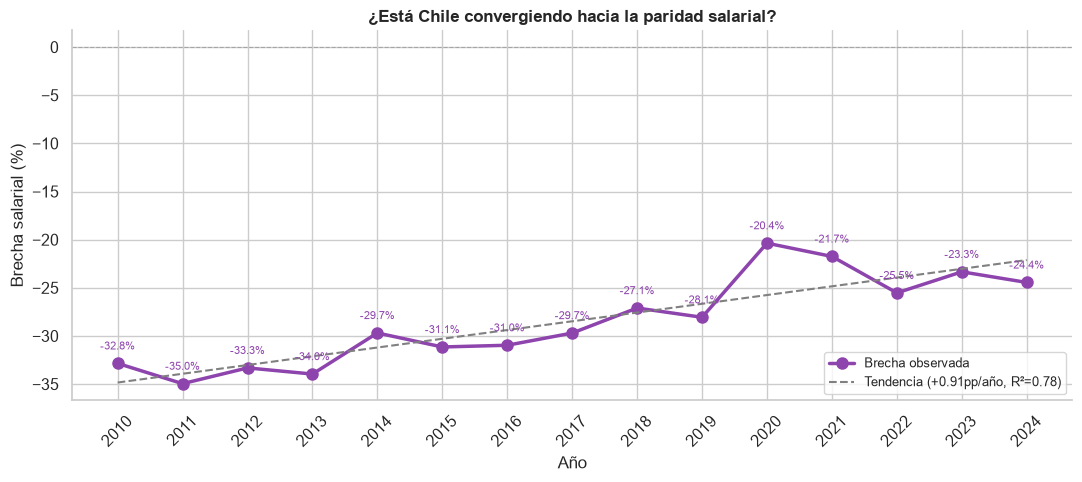

Tendencia: +0.908 pp/año (p=0.0000)


In [2]:
nac = brecha_nac[brecha_nac['AREA_REF']=='_T'].sort_values('AÑO').dropna(subset=['OBS_VALUE'])
slope, intercept, r, p, se = stats.linregress(nac['AÑO'], nac['OBS_VALUE'])
trend = slope * nac['AÑO'] + intercept
anio_paridad = int(-intercept/slope) if slope<0 else None

fig,ax = plt.subplots(figsize=(11,5))
ax.plot(nac['AÑO'],nac['OBS_VALUE'],'o-',color='#8e44ad',linewidth=2.5,markersize=8,label='Brecha observada')
ax.plot(nac['AÑO'],trend,'--',color='gray',linewidth=1.5,label=f'Tendencia ({slope:+.2f}pp/año, R²={r**2:.2f})')
if anio_paridad and anio_paridad>nac['AÑO'].max():
    anios_ext = np.arange(nac['AÑO'].max()+1,min(anio_paridad+1,2080))
    ax.plot(anios_ext,slope*anios_ext+intercept,':',color='#27ae60',linewidth=1.5,alpha=0.6,label=f'Proyección → paridad ≈{anio_paridad}')
    ax.axvline(anio_paridad,color='#27ae60',linestyle=':',linewidth=1.2)
for _,row in nac.iterrows():
    ax.annotate(f"{row['OBS_VALUE']:.1f}%",(row['AÑO'],row['OBS_VALUE']),
                textcoords='offset points',xytext=(0,10),ha='center',fontsize=8,color='#8e44ad')
ax.axhline(0,color='gray',linewidth=0.8,linestyle='--',alpha=0.5)
ax.set_xlabel('Año'); ax.set_ylabel('Brecha salarial (%)')
ax.set_title('¿Está Chile convergiendo hacia la paridad salarial?',fontsize=12,fontweight='bold')
ax.legend(fontsize=9); ax.set_xticks(nac['AÑO'].unique()); ax.tick_params(axis='x',rotation=45)
sns.despine(); plt.tight_layout()
plt.savefig('outputs/figures/convergencia.png',dpi=150,bbox_inches='tight')
plt.show()
print(f'Tendencia: {slope:+.3f} pp/año (p={p:.4f})')
if anio_paridad: print(f'Proyección de paridad: ≈{anio_paridad}')

### Interpretación

La tendencia responde la pregunta más importante: **¿estamos convergiendo y a qué velocidad?**

Si el coeficiente es negativo y significativo (p<0.05), hay reducción real de la brecha — aunque la proyección de paridad puede ser en décadas. Muchos países muestran reducción inicial rápida (incorporación femenina al mercado laboral) seguida de una brecha residual persistente que solo cede ante intervención activa.

## 2. Heatmap regional: geografía de la desigualdad

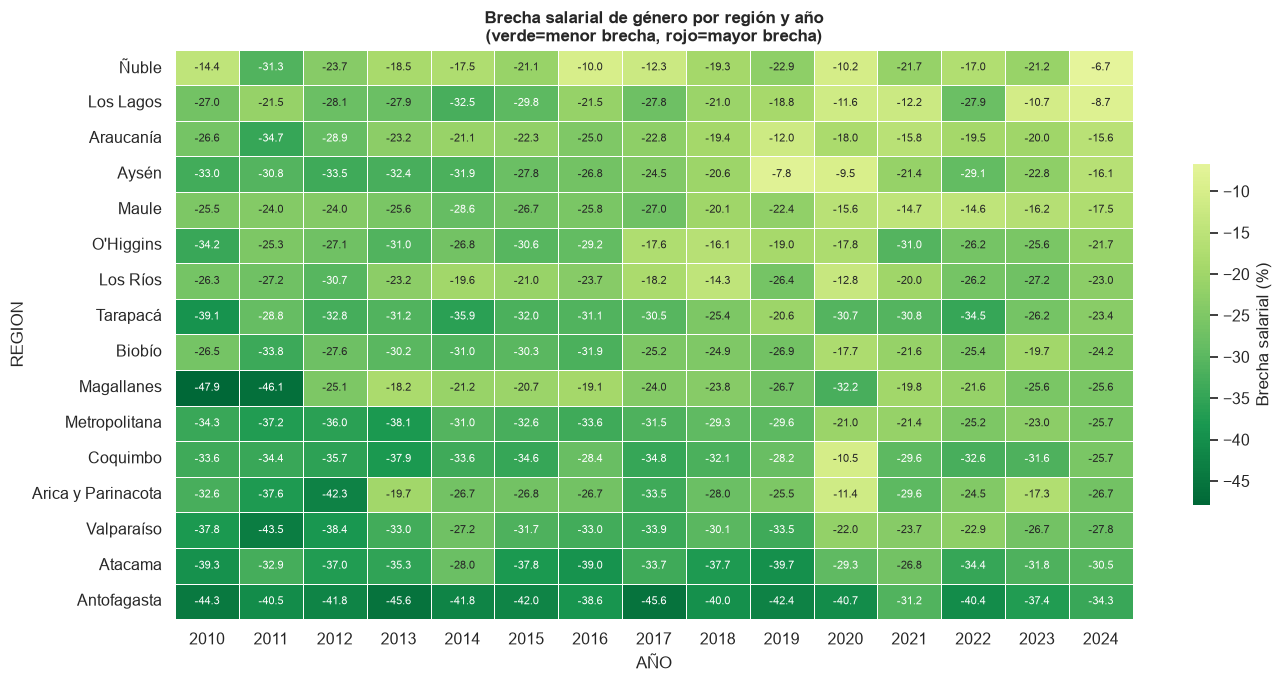

In [3]:
reg = brecha_nac[brecha_nac['AREA_REF']!='_T'].copy()
reg['REGION'] = reg['AREA_REF'].astype(str).map(LABELS_REGION).fillna(reg['AREA_REF'])
pivot_reg = reg.pivot_table(index='REGION',columns='AÑO',values='OBS_VALUE')
pivot_reg = pivot_reg.dropna(thresh=int(len(pivot_reg.columns)*0.5))
anio_ult = sorted(pivot_reg.columns)[-1]
pivot_reg = pivot_reg.sort_values(anio_ult, ascending=False)

fig,ax = plt.subplots(figsize=(14,7))
sns.heatmap(pivot_reg,ax=ax,cmap='RdYlGn_r',center=0,
            annot=True,fmt='.1f',annot_kws={'size':8},
            linewidths=0.5,cbar_kws={'label':'Brecha salarial (%)','shrink':0.6})
ax.set_title('Brecha salarial de género por región y año\n(verde=menor brecha, rojo=mayor brecha)',
             fontsize=12,fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/figures/heatmap_regional.png',dpi=150,bbox_inches='tight')
plt.show()

### Interpretación

El heatmap muestra simultáneamente nivel, variación regional y tendencia temporal.

**Patrones esperables:**
- **Regiones mineras (Antofagasta, Tarapacá)**: brechas altas porque la minería está masculinizada y sus altos salarios elevan el promedio masculino regional sin elevar el femenino.
- **Región Metropolitana**: brecha moderada con alta heterogeneidad interna (finanzas y TIC masculinizados).

La lectura horizontal muestra si la brecha en esa región converge o diverge en el tiempo.

## 3. Chile en perspectiva OCDE

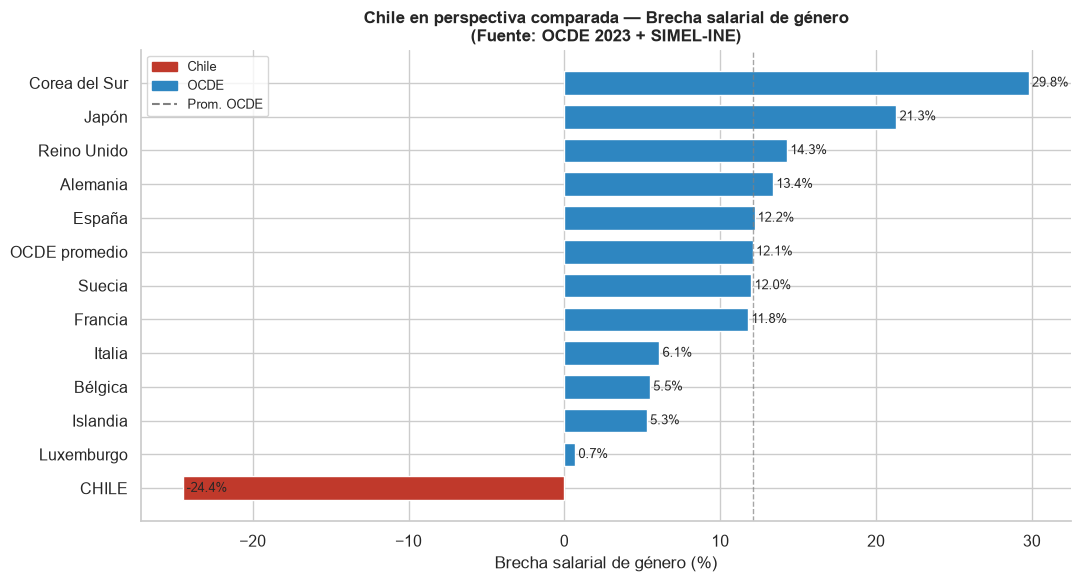

In [4]:
benchmark = pd.DataFrame({
    'País':['Luxemburgo','Islandia','Bélgica','Italia','Francia','Suecia',
            'España','OCDE promedio','Alemania','Reino Unido','Japón','CHILE','Corea del Sur'],
    'Brecha':[0.7,5.3,5.5,6.1,11.8,12.0,12.2,12.1,13.4,14.3,21.3,None,29.8],
    'Tipo':['OCDE']*7+['OCDE']+['OCDE']*3+['Chile']+['OCDE']
})
# Usar último dato Chile de la serie
brecha_chile = brecha_nac[brecha_nac['AREA_REF']=='_T']['OBS_VALUE'].dropna().iloc[-1]
benchmark.loc[benchmark['País']=='CHILE','Brecha'] = brecha_chile
benchmark = benchmark.sort_values('Brecha')

fig,ax = plt.subplots(figsize=(11,6))
colores = ['#c0392b' if t=='Chile' else '#2e86c1' for t in benchmark['Tipo']]
bars = ax.barh(benchmark['País'],benchmark['Brecha'],color=colores,edgecolor='white',height=0.7)
for bar,v in zip(bars,benchmark['Brecha']):
    if not pd.isna(v): ax.text(v+0.2,bar.get_y()+bar.get_height()/2,f'{v:.1f}%',va='center',fontsize=9)
ax.axvline(12.1,color='gray',linestyle='--',linewidth=1,alpha=0.7,label='Promedio OCDE (12.1%)')
ax.set_xlabel('Brecha salarial de género (%)')
ax.set_title('Chile en perspectiva comparada — Brecha salarial de género\n(Fuente: OCDE 2023 + SIMEL-INE)',
             fontsize=12,fontweight='bold')
from matplotlib.patches import Patch; from matplotlib.lines import Line2D
ax.legend(handles=[Patch(color='#c0392b',label='Chile'),Patch(color='#2e86c1',label='OCDE'),
                   Line2D([0],[0],color='gray',linestyle='--',label='Prom. OCDE')],fontsize=9)
sns.despine(); plt.tight_layout()
plt.savefig('outputs/figures/benchmark_ocde.png',dpi=150,bbox_inches='tight')
plt.show()

### Interpretación

Chile se ubica **por encima del promedio OCDE** en brecha salarial. Los países con menor brecha comparten:
1. **Transparencia salarial obligatoria** — empresas deben reportar y justificar diferencias
2. **Permisos parentales compartidos** y no transferibles para padres
3. **Acceso universal a cuidado infantil** desde edades tempranas
4. **Negociación colectiva amplia** que reduce la discrecionalidad salarial

Chile ha avanzado en algunos frentes (Ley Karin, Chile Crece Contigo), pero el ritmo de reducción sigue siendo lento frente a pares OCDE.

> **Nota metodológica:** La comparación internacional es indicativa — los países usan distintas definiciones de brecha (salario hora vs. mensual, todos los ocupados vs. solo asalariados).